## BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [9]:
import copy
from pathlib import Path
import sys
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, env, run_manager, plot_util, util
from predhpc.neurons import learning_neurons, two_comp_neurons

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Define some functions

In [4]:
def learn(env_params, agent_params, CA3_PC_params, CA1_params, 
          num_rewards=200, max_num_steps=10000, 
          weight_recording_freq=100, use_Hebbian=False, 
          num_target_reaches_for_btsp=2):

    print_vals = {
        "Agent dt": agent_params["dt"],
        "# CA3 PCs": CA3_PC_params["n"], 
        "# CA1s": CA1_params["n"], 
        "CA1 init at 0": CA1_params["init_weights_zero"], 
        "CA1 init scale": CA1_params["w_init_scale"], 
        "CA1 BTSP tau": CA1_params["btsp_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps,
        "Weight recording frequency": weight_recording_freq,
        "Hebbian learning": use_Hebbian, 
        "number of target reaches for BTSP": target_reach_num_for_btsp,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        weight_recording_freq=weight_recording_freq,
        use_Hebbian=use_Hebbian,
        target_reach_num_for_btsp=target_reach_num_for_btsp
    )
    
    return Env, Ag, CA3_PCs, CA1s

## Reload

In [5]:
import importlib
importlib.reload(agent)
importlib.reload(learning_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

## T-maze BTSP

 69%|█████████████████████████▍           | 2755/4000 [00:02<00:01, 1010.77it/s]


Trajectory lengths (11) to date: 5.01 +/- 0.32 sec each
Trajectory lengths (11) to date: 250.55 +/- 15.86 steps each


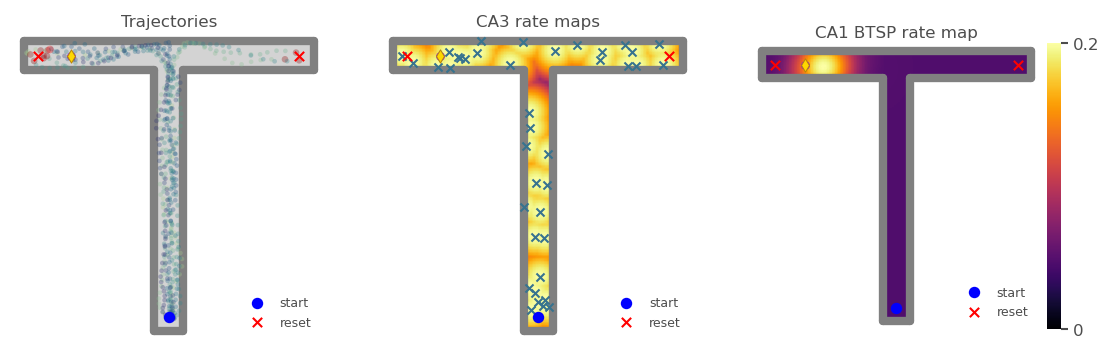

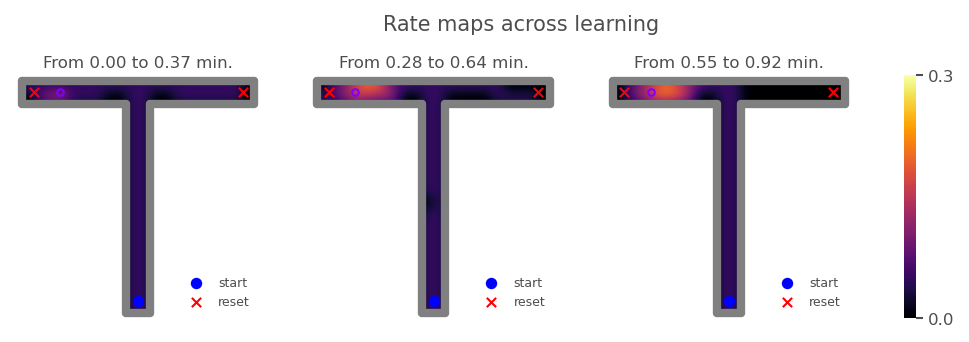

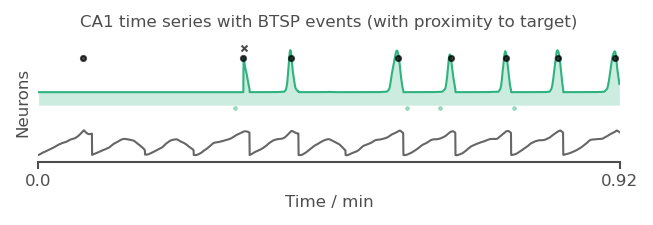

In [6]:
Env, Ag, _, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
    run_manager.ENV_PARAMS_T_MAZE, 
    run_manager.AGENT_PARAMS_T_MAZE, 
    run_manager.CA3_PC_PARAMS_T_MAZE, 
    run_manager.CA1_PARAMS_T_MAZE, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    btsp_after_num_target_reaches=2,
    two_compartment=False
)

## BTSP filtered inputs

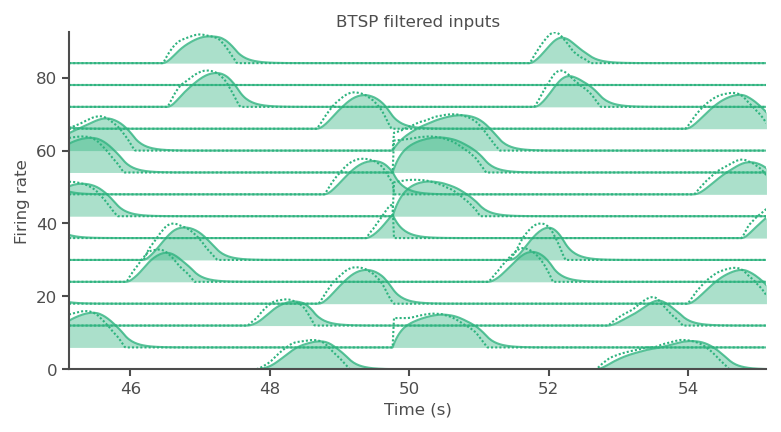

In [7]:
CA1s.plot_btsp_filtered("CA3_PCs", t_start=-10, chosen_neurons=np.arange(15));

## Two-compartment neuron

In [30]:
import importlib
importlib.reload(agent)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

In [31]:
Ag_params = copy.copy(run_manager.AGENT_PARAMS_T_MAZE)
Ag_params["left_arm_prop"] = 1.0

CA1_two_comp_params = copy.copy(run_manager.CA1_TWO_COMP_PARAMS)

100%|██████████████████████████████████████| 4000/4000 [00:05<00:00, 708.79it/s]


Only reached the reward 16 times (target: 200).
Trajectory lengths (17) to date: 4.71 +/- 0.49 sec each
Trajectory lengths (17) to date: 235.29 +/- 24.63 steps each


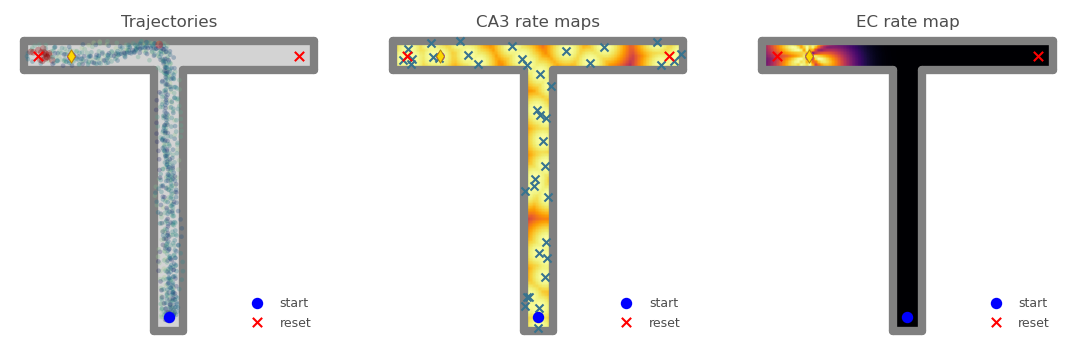

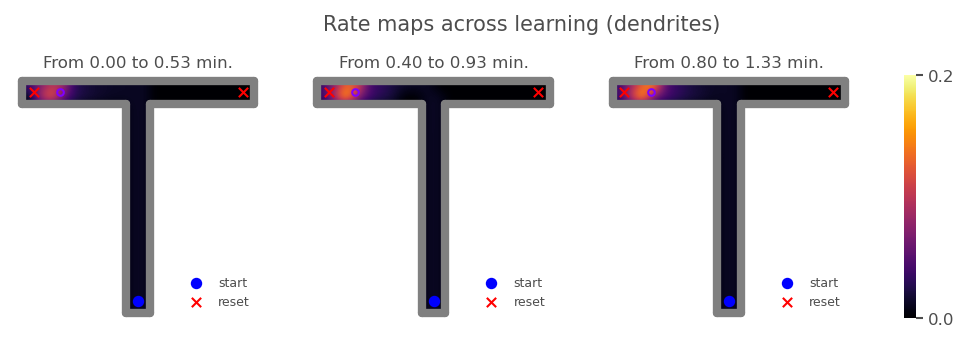

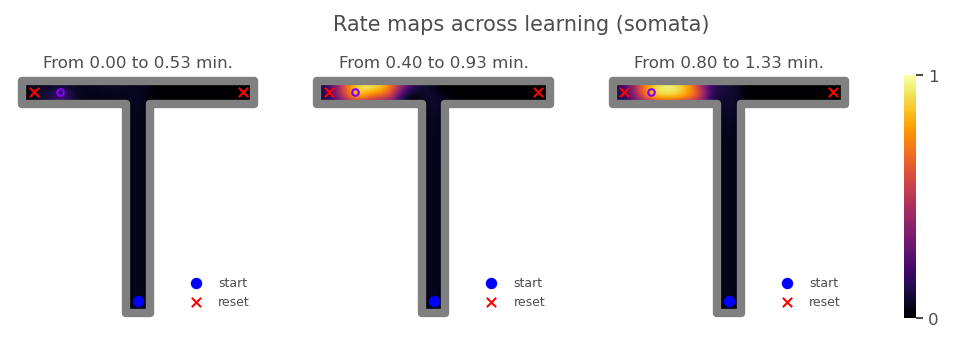

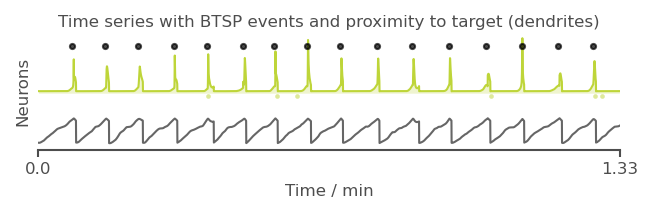

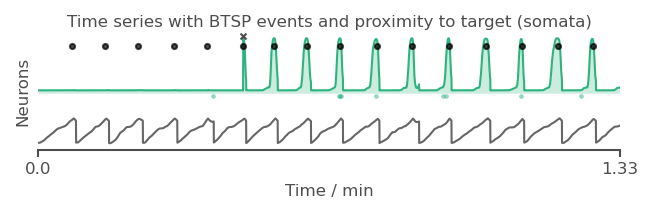

In [32]:
Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
    agent_params=Ag_params,
    CA1_params=CA1_two_comp_params,
    max_num_steps=4000, 
    btsp_after_num_target_reaches=6,
    two_compartment=True,
)

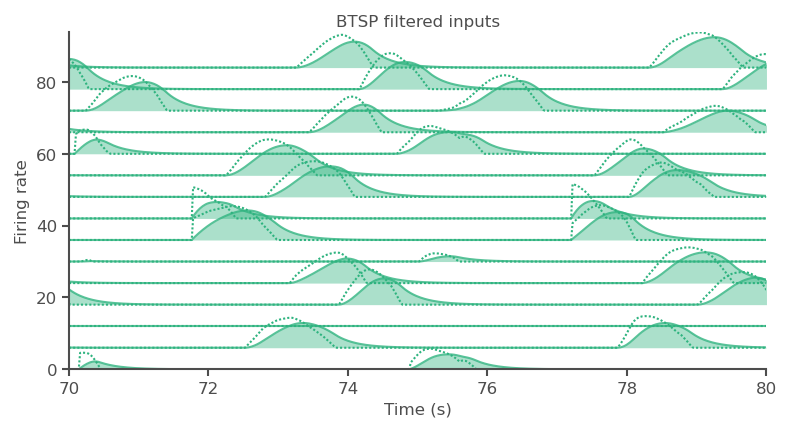

In [26]:
CA1s.SomaCompartment.plot_btsp_filtered("CA3_PCs", t_start=-10, chosen_neurons=np.arange(15));

## Developments
- Make BTSP two-directional (asymmetrical)
- Generate BTSP from two-compartment neuron
- Add in an inhibitory neuron

## Make EC cells ObjectCells
- FF + PlaceCells

## Look at integrating previous firing rates for FF layers (as recurrence)
- Enable time-dependency via fixed weights
- Fix plot_rate_maps() to avoid infinite recursion: seperate out FF from recurrent inputs?